In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'

pathcsv=pathfile+'CSV/'


data= 'Subjects_Functional_Structural_Parameters.xlsx'
df = pd.read_excel(pathcsv+data)

df.head()

,sub,sex,age,group,JND_P,IHD,EstimatedTotalIntraCranialVol,postcentral_lh,precentral_lh,postcentral_rh,precentral_rh,CC_Posterior,CC_Mid_Posterior,CC_Central,CC_Mid_Anterior,CC_Anterior
0,sub-01,F,25,Y,9.56,0.534027,1.601936e+06,12151,13519,11836,13247,993.9,605.0,586.7,666.7,944.6
1,sub-02,M,27,Y,6.69,0.570600,1.902124e+06,12527,16248,13068,16822,1015.4,425.5,400.1,439.6,922.7
2,sub-03,F,28,Y,12.92,-0.140120,1.730076e+06,13346,14411,11596,14849,723.5,446.6,717.7,571.2,708.0
3,sub-05,F,21,Y,1.95,0.488581,1.714908e+06,11553,13616,11595,13756,888.9,444.6,444.4,395.5,840.7
4,sub-06,F,25,Y,2.54,0.578001,1.546827e+06,9204,12872,9348,12538,770.1,476.4,658.5,563.1,703.9


In [43]:
# Pre-processing the data
# Relative measure of the volume mesures, for all columns, to the estimated total intracranial volume for each subject

df= df.rename(columns={"EstimatedTotalIntraCranialVol": "eTIV"})

# Assuming 'ICV' is the column name for intracranial volume in your DataFrame
colums_to_normalize = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh", "CC_Posterior", "CC_Mid_Posterior", "CC_Central", "CC_Mid_Anterior", "CC_Anterior"]

df_params_norm = df.copy()
for col in colums_to_normalize:
    df_params_norm[col] = (df_params_norm[col] / df_params_norm['eTIV']) #* 1000  # Scale to per 1000 units of intracranial volume

df.columns

Index(['sub', 'sex', 'age', 'group', 'JND_P', 'IHD', 'eTIV', 'postcentral_lh',
       'precentral_lh', 'postcentral_rh', 'precentral_rh', 'CC_Posterior',
       'CC_Mid_Posterior', 'CC_Central', 'CC_Mid_Anterior', 'CC_Anterior'],
      dtype='str')

Index(['sub', 'sex', 'age', 'group', 'JND_P', 'IHD', 'eTIV', 'postcentral_lh',
       'precentral_lh', 'postcentral_rh', 'precentral_rh', 'CC_Posterior',
       'CC_Mid_Posterior', 'CC_Central', 'CC_Mid_Anterior', 'CC_Anterior'],
      dtype='str')
                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     15.16
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.21e-06
Time:                        15:25:57   Log-Likelihood:                -109.37
No. Observations:                  42   AIC:                             226.7
Df Residuals:                      38   BIC:                             233.7
Df Model:                           3                                         
Covariance Type:            nonrobust   

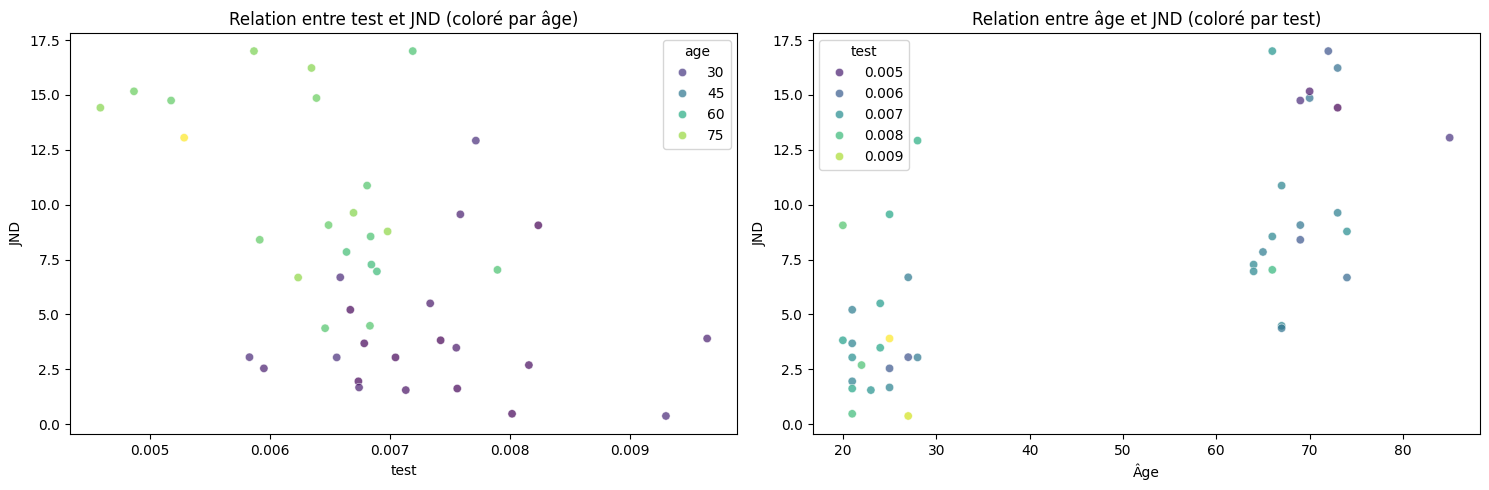

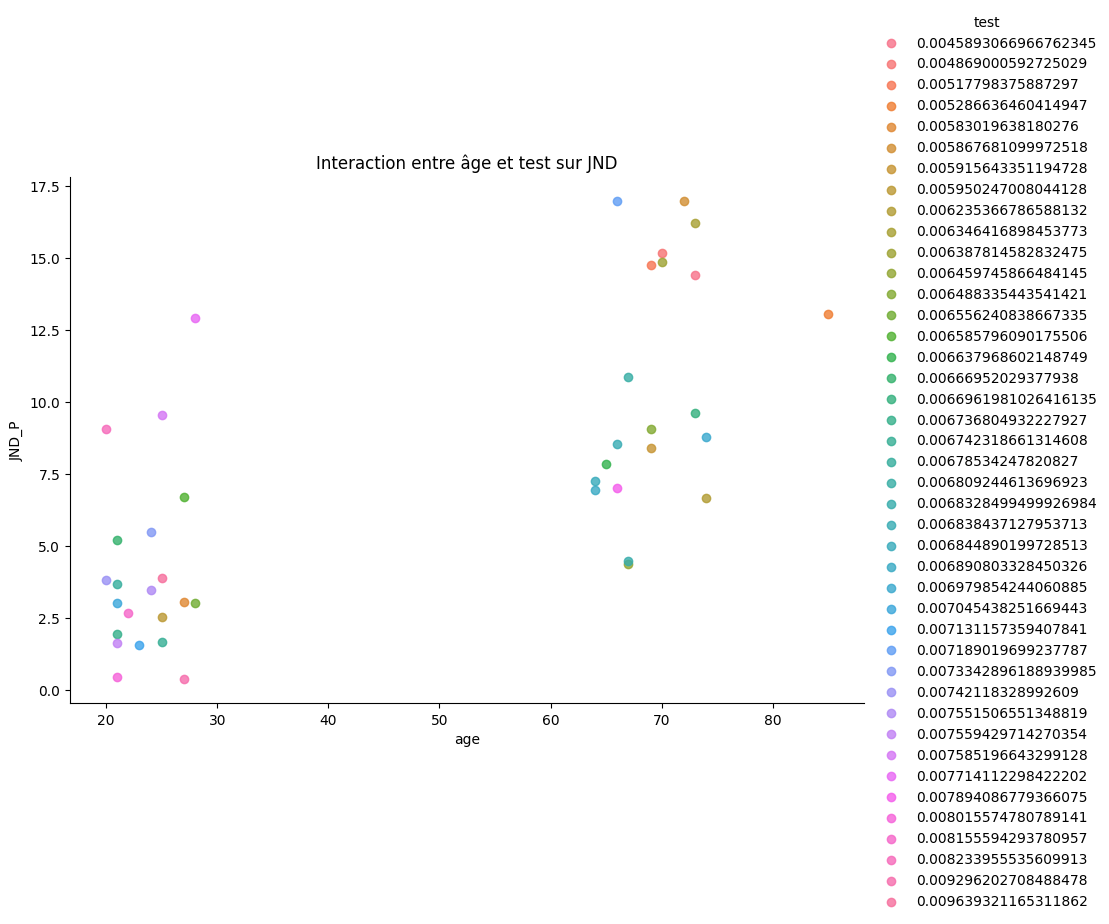

In [44]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Initialisation
pvaDTIlue = []
pvaAge = []
pvaInteraction = []  # Pour stocker les p-valeurs du terme d'interaction

print(df.columns)
dftest=pd.DataFrame({
    'test': df_params_norm['postcentral_lh'],
    'age': df_params_norm['age'],
    'JND_P': df_params_norm['JND_P']
})

# 1. Préparation des variables pour la régression
dftest['test_x_age'] = dftest['test'] * dftest['age']  # Terme d'interaction

# 2. Régression avec interaction
X = dftest[['test', 'age', 'test_x_age']]  # Ajout du terme d'interaction
X = sm.add_constant(X)  # Ajoute une constante pour l'interception
y = dftest['JND_P']  # Variable à expliquer

# 3. Ajuster le modèle de régression multiple
model = sm.OLS(y, X).fit()

# 4. Extraire les p-valeurs
pvaDTIlue.append(model.pvalues['test'])
pvaAge.append(model.pvalues['age'])
pvaInteraction.append(model.pvalues['test_x_age'])

# 5. Afficher le résumé du modèle
print(model.summary())

# 6. Afficher les résultats de manière claire
print("\n--- Résultats de la régression ---")
print(f"Coefficient de test : {model.params['test']:.4f}")
print(f"P-valeur de test : {model.pvalues['test']:.4f}")
print(f"Coefficient de l'âge : {model.params['age']:.4f}")
print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
print(f"Coefficient de l'interaction (test × âge) : {model.params['test_x_age']:.4f}")
print(f"P-valeur de l'interaction : {model.pvalues['test_x_age']:.4f}")
print(f"R-carré : {model.rsquared:.3f}")
print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 7. Visualisation
plt.figure(figsize=(15, 5))

# Scatter plot : test vs JND, coloré par âge
plt.subplot(1, 2, 1)
sns.scatterplot(data=dftest, x='test', y='JND_P', hue='age', palette='viridis', alpha=0.7)
plt.title("Relation entre test et JND (coloré par âge)")
plt.xlabel("test")
plt.ylabel("JND")

# Scatter plot : Âge vs JND, coloré par test
plt.subplot(1, 2, 2)
sns.scatterplot(data=dftest, x='age', y='JND_P', hue='test', palette='viridis', alpha=0.7)
plt.title("Relation entre âge et JND (coloré par test)")
plt.xlabel("Âge")
plt.ylabel("JND")

plt.tight_layout()
plt.show()

# 8. Visualisation de l'interaction (optionnel)
sns.lmplot(data=dftest, x='age', y='JND_P', hue='test', lowess=True, height=6, aspect=1.5)
plt.title("Interaction entre âge et test sur JND")
plt.show()